# UPD Course Syllabi RAG

## Step 1 - Retrieve UPD Math Syllabi

We scrape the UPD Math syllabi from the [UPD IMath website] (https://math.upd.edu.ph/courses/undergraduate-courses). To supplement this information, we also scrape the tables from UP CRS course catalog and schedule of classes.

In [17]:
#Import all packages

import time
import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
from pinecone import Pinecone
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpointEmbeddings, HuggingFaceEndpoint, ChatHuggingFace
from langchain_together import ChatTogether
from langchain_pinecone import PineconeVectorStore
from langchain_huggingface import HuggingFaceEndpoint
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
import json
from IPython.display import display, Markdown
import io
import re
import gradio as gr

In [ ]:
url = "https://math.upd.edu.ph/courses/undergraduate-courses"
folder = "UPD Math Syllabi"

if not os.path.exists(folder):
    os.makedirs(folder)

# 1. Get the page content
print("Fetching page...")
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, 'html.parser')

# 2. Find all <a> tags where the text contains "Syllabus"
syllabus_links = soup.find_all('a', string=lambda text: text and "Syllabus" in text)

print(f"Found {len(syllabus_links)} syllabi. Starting download...")

for link in syllabus_links:
    pdf_url = link.get('href')
    # Use the link text (e.g., "Math 2 Syllabus") as the filename
    file_name = link.text.strip().replace(" ", "_").replace("/", "-") + ".pdf"
    file_path = os.path.join(folder, file_name)
    
    try:
        # 3. Download the binary content of the PDF
        pdf_res = requests.get(pdf_url, timeout=20)
        if pdf_res.status_code == 200:
            with open(file_path, 'wb') as f:
                f.write(pdf_res.content)
            print(f"Successfully saved: {file_name}")
    except Exception as e:
        print(f"Failed to download {file_name}: {e}")

print("\nTask complete!")

Fetching page...
Found 33 syllabi. Starting download...
Successfully saved: Math_2_Syllabus.pdf
Successfully saved: Math_10_Syllabus.pdf
Successfully saved: Math_20_Syllabus.pdf
Successfully saved: Math_21_Syllabus.pdf
Successfully saved: Math_22_Syllabus.pdf
Successfully saved: Math_23_Syllabus.pdf
Successfully saved: Math_30_Syllabus.pdf
Successfully saved: Math_40_Syllabus.pdf
Successfully saved: Math_108_Syllabus.pdf
Successfully saved: Math_110.1_Syllabus.pdf
Successfully saved: Math_110.2_Syllabus.pdf
Successfully saved: Math_110.3_Syllabus.pdf
Successfully saved: Math_117_Syllabus.pdf
Successfully saved: Math_122_Syllabus.pdf
Successfully saved: Math_123.1_Syllabus.pdf
Successfully saved: Math_123.2_Syllabus.pdf
Successfully saved: Math_126_Syllabus.pdf
Successfully saved: Math_128_Syllabus.pdf
Successfully saved: Math_133_Syllabus.pdf
Successfully saved: Math_140_Syllabus.pdf
Successfully saved: Math_142_Syllabus.pdf
Successfully saved: Math_146_Syllabus.pdf
Successfully saved:

In [2]:
course_catalog_url = "https://crs.upd.edu.ph/course_catalog/index/Math"
schedule_url = "https://crs.upd.edu.ph/schedule/120252/Math"

course_catalog_html = requests.get(course_catalog_url)

soup = BeautifulSoup(course_catalog_html.text, 'html.parser')

course_catalog_table = None
for table in soup.find_all('table'):
    if "Course code" in table.get_text():
        course_catalog_table = table
        break

course_catalog_table = io.StringIO(str(course_catalog_table))    

course_catalog_table = pd.read_html(course_catalog_table)[0]
print(course_catalog_table.shape)
course_catalog_table.head()

(153, 4)


,Course code & No.,Course Title,Course Description,Offering Unit
0,MATH I,Fundamental Concepts and Applications of Mathe...,NaN,MATH
1,Math 2,Mathematics in Everyday Life,NaN,MATH
2,Math 10,"Mathematics, Culture and Society",NaN,MATH
3,Math 12,Business Mathematics,NaN,MATH
4,Math 18,Basic Concepts of Mathematics,NaN,MATH


In [3]:
course_schedule_html = requests.get(schedule_url)

soup = BeautifulSoup(course_schedule_html.text, 'html.parser')

course_schedule_table = None
for table in soup.find_all('table'):
    if "Class Code" in table.get_text():
        course_schedule_table = table
        break

course_schedule_table = io.StringIO(str(course_schedule_table))    

course_schedule_table = pd.read_html(course_schedule_table)[0]
print(course_schedule_table.shape)
course_schedule_table.head()

(302, 8)


,Class Code,Class,Credits,Schedule Instructor(s) Remarks,Enlisting Unit : Block Block Remarks,Available Slots / Total Slots,Demand,Restrictions
0,39252,Math 2 THR,3.0,"TTh 8:30-10AM lec MBAN 306 ONA, JEANINE CONCE...",MATH,0 / 40,0,For: BS Tour(15 slots)
1,39254,Math 2 THU,3.0,"TTh 10-11:30AM lec MBAN 306 CONSORTE, ODESSA ...",MATH,0 / 46,0,"For: BA Film(10 slots), BA CommRes(10 slots)"
2,39253,Math 2 THW,3.0,"TTh 1-2:30PM lec MBAN 306 CONSORTE, ODESSA Fa...",MATH,0 / 45,0,For: BS Tour(15 slots)
3,39375,Math 2 THX,3.0,"TTh 2:30-4PM lec MBAN 305 ONA, JEANINE CONCEP...",MATH,0 / 35,0,NaN
4,39255,Math 2 WFR,3.0,"WF 8:30-10AM lec MBAN 306 DONATO, JUDY ANN Fa...",MATH,0 / 41,0,"For: B LIS(2 slots), BS HE(4 slots), BA (Ling)..."


In [4]:
# 1. Clean the 'Course Catalog' key
# Ensure 'Math 2' doesn't have hidden spaces
course_catalog_table['join_key'] = course_catalog_table['Course code & No.'].str.strip()

# 2. Extract the base course from the 'Schedule' Class column
# This regex looks for the course name and number, stopping before the section
# Example: It turns "Math 2 THR" -> "Math 2" and "Math 110.1 WFU" -> "Math 110.1"
def extract_course_base(class_string):
    # Matches the course name and number (including dots for 110.1)
    match = re.match(r'^([a-zA-Z]+\s+\d+(?:\.\d+)?)', str(class_string).strip())
    return match.group(1) if match else class_string

course_schedule_table['join_key'] = course_schedule_table['Class'].apply(extract_course_base)

# 3. Perform the Left Join
# We keep all rows from the Schedule and add Title/Description from Catalog
df_merged = pd.merge(
    course_schedule_table, 
    course_catalog_table[['join_key', 'Course Title', 'Course Description', 'Offering Unit']], 
    on='join_key', 
    how='left'
)

# 4. Clean up: Remove the temporary join key
df_merged = df_merged.drop(columns=['join_key'])
df_merged = df_merged.fillna("")

print(df_merged['Schedule  Instructor(s)  Remarks'][0])
print(df_merged.shape)
print(df_merged.columns)
df_merged.head()

TTh 8:30-10AM lec MBAN 306  ONA, JEANINE CONCEPCION Face to face with online components.
(302, 11)
Index(['Class Code', 'Class', 'Credits', 'Schedule  Instructor(s)  Remarks',
       'Enlisting Unit : Block Block Remarks',
       'Available Slots /  Total Slots', 'Demand', 'Restrictions',
       'Course Title', 'Course Description', 'Offering Unit'],
      dtype='str')


,Class Code,Class,Credits,Schedule Instructor(s) Remarks,Enlisting Unit : Block Block Remarks,Available Slots / Total Slots,Demand,Restrictions,Course Title,Course Description,Offering Unit
0,39252,Math 2 THR,3.0,"TTh 8:30-10AM lec MBAN 306 ONA, JEANINE CONCE...",MATH,0 / 40,0,For: BS Tour(15 slots),Mathematics in Everyday Life,,MATH
1,39254,Math 2 THU,3.0,"TTh 10-11:30AM lec MBAN 306 CONSORTE, ODESSA ...",MATH,0 / 46,0,"For: BA Film(10 slots), BA CommRes(10 slots)",Mathematics in Everyday Life,,MATH
2,39253,Math 2 THW,3.0,"TTh 1-2:30PM lec MBAN 306 CONSORTE, ODESSA Fa...",MATH,0 / 45,0,For: BS Tour(15 slots),Mathematics in Everyday Life,,MATH
3,39375,Math 2 THX,3.0,"TTh 2:30-4PM lec MBAN 305 ONA, JEANINE CONCEP...",MATH,0 / 35,0,,Mathematics in Everyday Life,,MATH
4,39255,Math 2 WFR,3.0,"WF 8:30-10AM lec MBAN 306 DONATO, JUDY ANN Fa...",MATH,0 / 41,0,"For: B LIS(2 slots), BS HE(4 slots), BA (Ling)...",Mathematics in Everyday Life,,MATH


Below we extract the Room and Professor information from the "Schedule  Instructor(s)  Remarks" column.

In [5]:
# Below we apply the extraction logic to the entire dataframe

def format_prof_name(name_str):
    """Converts 'LASTNAME, FIRSTNAME' to 'FIRSTNAME LASTNAME'"""
    parts = name_str.split(',')
    if len(parts) == 2:
        first_name_parts = parts[1].strip().split()
        # Drop the isolated trailing 'F' (from words like 'Face')
        if len(first_name_parts) > 0 and first_name_parts[-1] == "F":
            first_name_parts.pop()
            
        first_name = " ".join(first_name_parts)
        return f"{first_name} {parts[0].strip()}"
    return name_str.strip()

def extract_info(entry):
    room = None
    prof = None
    
    if pd.isna(entry):
        return pd.Series([room, prof])
        
    entry_str = str(entry).strip()
    
    # 1. Match the initial schedule part (Days, Time, Type)
    # The rest of the string is captured in group 4
    sched_pattern = r"^([a-zA-Z]+)\s+([\d:a-zA-Z-]+)\s+([a-zA-Z]+)\s+(.*)$"
    match = re.match(sched_pattern, entry_str)
    
    if match:
        rest = match.group(4)
        
        # 2. Extract Professor. They are usually ALL CAPS formatted as "LAST, FIRST"
        # We also account for multiple professors separated by a slash (/)
        prof_pattern = r"([A-ZÑ\-\s\.]+,\s+[A-ZÑ\-\s\.]+(?:\s*/\s*[A-ZÑ\-\s\.]+,\s+[A-ZÑ\-\s\.]+)*)"
        prof_match = re.search(prof_pattern, rest)
        
        if prof_match:
            prof_raw = prof_match.group(1).strip()
            
            # The room is everything before the professor's name
            room = rest[:prof_match.start()].strip()
            
            # Format and join professor names
            profs = []
            for p in prof_raw.split('/'):
                profs.append(format_prof_name(p))
            prof = ", ".join(profs)
        else:
            # If no professor pattern matched, the remaining text is likely just the room
            room = rest.strip()
            
    return pd.Series([room, prof])

# 2. Extract from the column to create 'Room' and 'Professor'
df_merged[['Room', 'Professor']] = df_merged['Schedule  Instructor(s)  Remarks'].apply(extract_info)

# Display the first few rows to verify the extraction
display(df_merged.head())

,Class Code,Class,Credits,Schedule Instructor(s) Remarks,Enlisting Unit : Block Block Remarks,Available Slots / Total Slots,Demand,Restrictions,Course Title,Course Description,Offering Unit,Room,Professor
0,39252,Math 2 THR,3.0,"TTh 8:30-10AM lec MBAN 306 ONA, JEANINE CONCE...",MATH,0 / 40,0,For: BS Tour(15 slots),Mathematics in Everyday Life,,MATH,MBAN 306,JEANINE CONCEPCION ONA
1,39254,Math 2 THU,3.0,"TTh 10-11:30AM lec MBAN 306 CONSORTE, ODESSA ...",MATH,0 / 46,0,"For: BA Film(10 slots), BA CommRes(10 slots)",Mathematics in Everyday Life,,MATH,MBAN 306,ODESSA CONSORTE
2,39253,Math 2 THW,3.0,"TTh 1-2:30PM lec MBAN 306 CONSORTE, ODESSA Fa...",MATH,0 / 45,0,For: BS Tour(15 slots),Mathematics in Everyday Life,,MATH,MBAN 306,ODESSA CONSORTE
3,39375,Math 2 THX,3.0,"TTh 2:30-4PM lec MBAN 305 ONA, JEANINE CONCEP...",MATH,0 / 35,0,,Mathematics in Everyday Life,,MATH,MBAN 305,JEANINE CONCEPCION ONA
4,39255,Math 2 WFR,3.0,"WF 8:30-10AM lec MBAN 306 DONATO, JUDY ANN Fa...",MATH,0 / 41,0,"For: B LIS(2 slots), BS HE(4 slots), BA (Ling)...",Mathematics in Everyday Life,,MATH,MBAN 306,JUDY ANN DONATO


## Step 2 - Chunking

After having retrieved the math course syllabi we then use *RecursiveCharacterTextSplitter* to split the documents into chunks by recursively splitting text using separators, starting at paragraphs, then sentences, then words thereby ensuring semantic coherence. 

Additionally, we display a histogram of the number of tokens in each document before chunking and then the number of tokens in each chunk. Now, for the tables retrieved from CRS, we chunk row by row making sure that for each chunk the header is appended so that the LLM has full context of the information in the row. Additionally, we create summary chunks for rows of the same course/professor (but may differ in other fields) so that the LLM may see all the context related to a single course/professor.   

Histogram saved as token_distribution.png


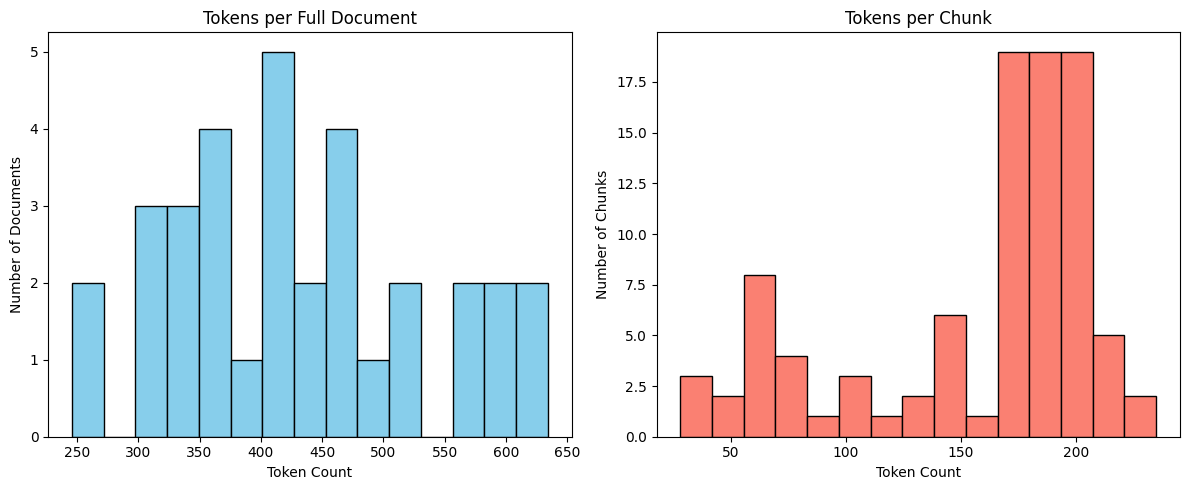

In [ ]:
# 1. Setup
path = "./UPD Math Syllabi"
tokenizer = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(tokenizer.encode(text))

# 2. Load and Count Full Documents
doc_counts = []
all_docs = []
for file in os.listdir(path):
    if file.endswith(".pdf"):
        loader = PyPDFLoader(os.path.join(path, file))
        data = loader.load()
        full_text = " ".join([d.page_content for d in data])
        doc_counts.append(count_tokens(full_text))
        all_docs.extend(data)

# 3. Chunk and Count Chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800, 
    chunk_overlap=80,
    separators=["\n\n", "\n", ". "]
)
chunks = splitter.split_documents(all_docs)
chunk_counts = [count_tokens(c.page_content) for c in chunks]

# 4. Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Document Histogram
ax[0].hist(doc_counts, bins=15, color='skyblue', edgecolor='black')
ax[0].set_title('Tokens per Full Document')
ax[0].set_xlabel('Token Count')
ax[0].set_ylabel('Number of Documents')

# Chunk Histogram
ax[1].hist(chunk_counts, bins=15, color='salmon', edgecolor='black')
ax[1].set_title('Tokens per Chunk')
ax[1].set_xlabel('Token Count')
ax[1].set_ylabel('Number of Chunks')

plt.tight_layout()
plt.savefig("token_distribution.png")
print("Histogram saved as token_distribution.png")

In [30]:
# Create chunks without including the index in the text
CRS_chunks = []
headers = " | ".join(df_merged.columns)

# .to_dict('records') turns each row into a dictionary {Column: Value} 
# and completely ignores the index.
for row_dict in df_merged.to_dict('records'):
    row_data = " | ".join(map(str, row_dict.values()))
    full_chunk = f"FIELDS: {headers}\nDATA: {row_data}"
    CRS_chunks.append(full_chunk)

print(CRS_chunks[0])

FIELDS: Class Code | Class | Credits | Schedule  Instructor(s)  Remarks | Enlisting Unit : Block Block Remarks | Available Slots /  Total Slots | Demand | Restrictions | Course Title | Course Description | Offering Unit
DATA: 39252 | Math 2 THR | 3.0 | TTh 8:30-10AM lec MBAN 306  ONA, JEANINE CONCEPCION Face to face with online components. | MATH | 0 /  40 | 0 | For: BS Tour(15 slots) | Mathematics in Everyday Life |  | MATH


Below we create the summary chunks for Professor and class.

In [6]:
# --- Create Summary Chunks ---

# 1. Class_Summary_Chunks
# Since we already defined `extract_course_base` earlier, we can reuse it to get the base course
df_merged['Base Course'] = df_merged['Class'].apply(extract_course_base)

Class_Summary_Chunks = []
class_summary_metadatas = []

for base_course, group in df_merged.groupby('Base Course'):
    summary_text = f"COURSE SUMMARY FOR: {base_course}\n\n"
    for _, row in group.iterrows():
        # Exclude 'Base Course' from the chunk text data
        row_dict = {col: row[col] for col in df_merged.columns if col != 'Base Course'}
        row_data = " | ".join([f"{k}: {v}" for k, v in row_dict.items()])
        summary_text += f"- {row_data}\n"
    
    Class_Summary_Chunks.append(summary_text)
    class_summary_metadatas.append({
        "summary_type": "Class",
        "course_title": group.iloc[0]["Course Title"],
        "offering_unit": group.iloc[0]["Offering Unit"]
    })

print(f"Created {len(Class_Summary_Chunks)} Class Summary Chunks.")

# 2. Prof_Summary_Chunks
# A row can have multiple professors separated by ", ". We'll explode them first.
df_prof = df_merged.copy()
df_prof['Professor'] = df_prof['Professor'].apply(
    lambda x: [p.strip() for p in str(x).split(',')] if pd.notna(x) and str(x).strip() and str(x).strip() != "None" else []
)
df_prof = df_prof.explode('Professor')
df_prof = df_prof[df_prof['Professor'] != ''] # exclude empty strings

Prof_Summary_Chunks = []
prof_summary_metadatas = []

for prof_name, group in df_prof.groupby('Professor'):
    if not prof_name or pd.isna(prof_name) or str(prof_name).strip() == "None":
        continue
        
    summary_text = f"PROFESSOR SUMMARY FOR: {prof_name}\n\n"
    for _, row in group.iterrows():
        row_dict = {col: row[col] for col in df_merged.columns if col != 'Base Course'}
        row_data = " | ".join([f"{k}: {v}" for k, v in row_dict.items()])
        summary_text += f"- {row_data}\n"
        
    Prof_Summary_Chunks.append(summary_text)
    prof_summary_metadatas.append({
        "summary_type": "Professor",
        "professor_name": prof_name,
        "offering_unit": group.iloc[0]["Offering Unit"]
    })

print(f"Created {len(Prof_Summary_Chunks)} Professor Summary Chunks.")

Created 61 Class Summary Chunks.
Created 135 Professor Summary Chunks.


In [7]:
print(Class_Summary_Chunks[0])
print(Prof_Summary_Chunks[0])

COURSE SUMMARY FOR: Math 10

- Class Code: 39262 | Class: Math 10 THR | Credits: 3.0 | Schedule  Instructor(s)  Remarks: TTh 8:30-10AM lec MBAN 305  OROPEZA, ALIP Face to face with online components. | Enlisting Unit : Block Block Remarks: MATH | Available Slots /  Total Slots: 0 /  44 | Demand: 0 | Restrictions: For: BS CD(5 slots), BS SW(10 slots), B SS(15 slots) | Course Title: Mathematics, Culture and Society | Course Description:  | Offering Unit: MATH | Room: MBAN 305 | Professor: ALIP OROPEZA
- Class Code: 39260 | Class: Math 10 THU | Credits: 3.0 | Schedule  Instructor(s)  Remarks: TTh 10-11:30AM lec MB 118  ARCEO, CARLENE PERPETUA Face to face with online components. | Enlisting Unit : Block Block Remarks: MATH | Available Slots /  Total Slots: 0 /  46 | Demand: 0 | Restrictions: For: BA (Ling)(10 slots), Psych(20 slots) | Course Title: Mathematics, Culture and Society | Course Description:  | Offering Unit: MATH | Room: MB 118 | Professor: CARLENE PERPETUA ARCEO
- Class Code:

## Step 3 - Embedding using BGE-M3

We will embed the chunks using BGE-M3 (through the HuggingFace API) an open source embedding model which supports both dense and sparse retrieval. 

Below we define the embedding model and test its functionality.

In [11]:
load_dotenv()

embeddings = HuggingFaceEndpointEmbeddings(
    model="BAAI/bge-m3",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_TOKEN")
)

# Added a basic 'try-except' for cleaner debugging
try:
    test_vector = embeddings.embed_query("What are the math courses in UP Diliman?")
    print(f"Success! Vector Length: {len(test_vector)}")
except Exception as e:
    print(f"Connection Error: {e}")
    print("Tip: Check if your Hugging Face token is 'Read' or 'Write' type.")

Success! Vector Length: 1024


Below, we embed all the chunks then upload the embedded chunks with their corresponding chunks to Pinecone for safekeeping.

In [ ]:
load_dotenv()

os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

#Upload to Pinecone
index_name = "updcoursessyllabindex"

print("Uploading chunks to Pinecone... this may take a minute.")

vectorstore = PineconeVectorStore.from_documents(
    documents=chunks, 
    embedding=embeddings, 
    index_name=index_name
)

print("Upload Complete! Your syllabi are now stored in the cloud.")

Uploading chunks to Pinecone... this may take a minute.
Upload Complete! Your syllabi are now stored in the cloud.


Below we embed and upload the granular CRS chunks. 

In [37]:
load_dotenv()

os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

#Upload to Pinecone
index_name = "updcoursessyllabindex"

print("Uploading CRS chunks to Pinecone... this may take a minute.")

metadatas = [
    {"class": row["Class"], "course_title": row["Course Title"], "offering_unit": row["Offering Unit"]} 
    for row in df_merged.to_dict('records')
]

print(f"Uploading {len(CRS_chunks)} CRS chunks to Pinecone...")

# 3. Use from_texts for raw string lists (batch_size helps with memory)
batch_size = 100
for i in range(0, len(CRS_chunks), batch_size):
    batch_texts = CRS_chunks[i : i + batch_size]
    batch_metas = metadatas[i : i + batch_size]
    
    # We use the existing vectorstore if it exists, or create it on the first loop
    if i == 0:
        vectorstore = PineconeVectorStore.from_texts(
            texts=batch_texts,
            embedding=embeddings,
            index_name=index_name,
            metadatas=batch_metas
        )
    else:
        vectorstore.add_texts(texts=batch_texts, metadatas=batch_metas)
    
    print(f"  [Progress] Uploaded {i + len(batch_texts)} / {len(CRS_chunks)} rows...")

print("\nUpload Complete! Your CRS Tables are now stored in the cloud.")

Uploading CRS chunks to Pinecone... this may take a minute.
Uploading 302 CRS chunks to Pinecone...
  [Progress] Uploaded 100 / 302 rows...
  [Progress] Uploaded 200 / 302 rows...
  [Progress] Uploaded 300 / 302 rows...
  [Progress] Uploaded 302 / 302 rows...

Upload Complete! Your CRS Tables are now stored in the cloud.


Below we check the number of tokens per summary chunk for the class and professor summary chunks. After this, embed the summary CRS chunks

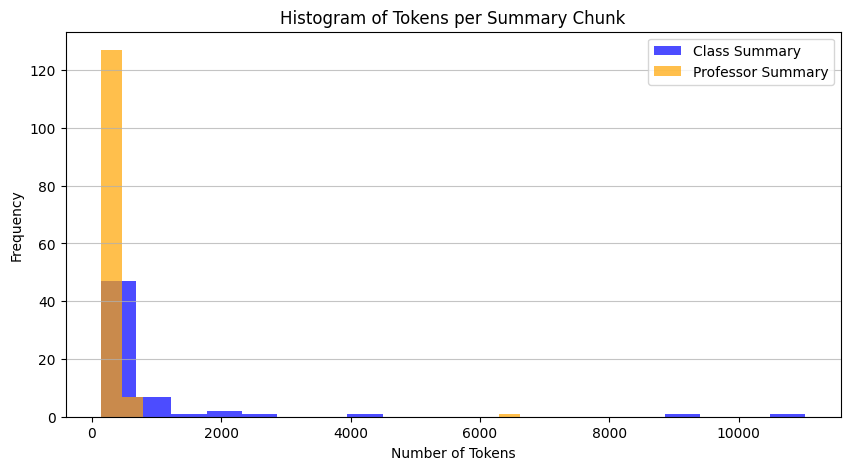

In [8]:
# Initialize tokenizer
tokenizer = tiktoken.get_encoding("cl100k_base")

# Calculate tokens for each chunk
class_tokens = [len(tokenizer.encode(chunk)) for chunk in Class_Summary_Chunks]
prof_tokens = [len(tokenizer.encode(chunk)) for chunk in Prof_Summary_Chunks]

# Create the histogram
plt.figure(figsize=(10, 5))
plt.hist(class_tokens, bins=20, alpha=0.7, label='Class Summary', color='blue')
plt.hist(prof_tokens, bins=20, alpha=0.7, label='Professor Summary', color='orange')
plt.title('Histogram of Tokens per Summary Chunk')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Since BGE-M3 is limited to only 8,192 tokens, we take all summary chunks exceeding 6000 tokens and split those into 2. 

In [9]:
new_class_chunks = []
new_class_metadatas = []

for chunk, meta in zip(Class_Summary_Chunks, class_summary_metadatas):
    tokens = tokenizer.encode(chunk)
    if len(tokens) > 6000:
        midpoint = len(tokens) // 2
        chunk1 = tokenizer.decode(tokens[:midpoint])
        chunk2 = tokenizer.decode(tokens[midpoint:])
        
        # Retain the header
        header_end = chunk.find('\n\n')
        header = chunk[:header_end+2] if header_end != -1 else ""
        if not chunk2.startswith(header.strip()):
            chunk2 = header + chunk2
            
        new_class_chunks.extend([chunk1, chunk2])
        new_class_metadatas.extend([meta.copy(), meta.copy()])
    else:
        new_class_chunks.append(chunk)
        new_class_metadatas.append(meta)

Class_Summary_Chunks = new_class_chunks
class_summary_metadatas = new_class_metadatas

new_prof_chunks = []
new_prof_metadatas = []

for chunk, meta in zip(Prof_Summary_Chunks, prof_summary_metadatas):
    tokens = tokenizer.encode(chunk)
    if len(tokens) > 6000:
        midpoint = len(tokens) // 2
        chunk1 = tokenizer.decode(tokens[:midpoint])
        chunk2 = tokenizer.decode(tokens[midpoint:])
        
        # Retain the header
        header_end = chunk.find('\n\n')
        header = chunk[:header_end+2] if header_end != -1 else ""
        if not chunk2.startswith(header.strip()):
            chunk2 = header + chunk2
            
        new_prof_chunks.extend([chunk1, chunk2])
        new_prof_metadatas.extend([meta.copy(), meta.copy()])
    else:
        new_prof_chunks.append(chunk)
        new_prof_metadatas.append(meta)

Prof_Summary_Chunks = new_prof_chunks
prof_summary_metadatas = new_prof_metadatas

print(f"Updated Class Summary Chunks count: {len(Class_Summary_Chunks)}")
print(f"Updated Professor Summary Chunks count: {len(Prof_Summary_Chunks)}")

Updated Class Summary Chunks count: 63
Updated Professor Summary Chunks count: 136


In [10]:
print(f"Updated Class Summary Chunks count: {len(Class_Summary_Chunks)}, Updated Class summary metadatas count: {len(class_summary_metadatas)}")
print(f"Updated Professor Summary Chunks count: {len(Prof_Summary_Chunks)}, Updated Professor summary metadatas count: {len(prof_summary_metadatas)}")

Updated Class Summary Chunks count: 63, Updated Class summary metadatas count: 63
Updated Professor Summary Chunks count: 136, Updated Professor summary metadatas count: 136


In [12]:
load_dotenv()
os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")


pc = Pinecone(api_key=os.environ.get('PINECONE_API_KEY'))
index_name = "updcoursessyllabindex"
index = pc.Index(index_name)

index.delete(filter={"summary_type": {"$eq": "Class"}})

print("Purge complete! All 'Class' summary vectors have been removed.")

# 1. Initialize the VectorStore connection once up front
vectorstore = PineconeVectorStore.from_existing_index(
    index_name=index_name, 
    embedding=embeddings
)

# Reduced batch size and a unified function with delays to prevent rate-limiting/timeouts
batch_size = 10 

def upload_in_batches(chunks, metadatas, chunk_type):
    print(f"\nUploading {len(chunks)} {chunk_type} chunks to Pinecone...")
    for i in range(0, len(chunks), batch_size):
        batch_texts = chunks[i : i + batch_size]
        batch_metas = metadatas[i : i + batch_size]
        
        success = False
        retries = 3
        
        while not success and retries > 0:
            try:
                # We simply use add_texts since the vectorstore is already initialized to the existing index
                vectorstore.add_texts(texts=batch_texts, metadatas=batch_metas)
                success = True
                print(f"  [Progress] Uploaded {i + len(batch_texts)} / {len(chunks)} {chunk_type} rows...")
                
                # Intentional pause to avoid overwhelming HuggingFace's free tier API
                time.sleep(2) 
            except Exception as e:
                retries -= 1
                print(f"  [Warning] API encountered an issue: {e.__class__.__name__}. Retrying in 10s... ({retries} left)")
                time.sleep(10)
                if retries == 0:
                    print(f"  [Error] Failed to upload batch after multiple retries. Exception: {e}")
                    raise e
                    
    print(f"{chunk_type} Chunks Upload Complete!")

# 2. Run the uploads safely
upload_in_batches(Class_Summary_Chunks, class_summary_metadatas, "Class Summary")
batch_size = 50 
upload_in_batches(Prof_Summary_Chunks, prof_summary_metadatas, "Professor Summary")

print("\nAll Summary Chunks Upload Complete!")

Purge complete! All 'Class' summary vectors have been removed.

Uploading 63 Class Summary chunks to Pinecone...
  [Progress] Uploaded 10 / 63 Class Summary rows...
  [Progress] Uploaded 20 / 63 Class Summary rows...
  [Progress] Uploaded 30 / 63 Class Summary rows...
  [Progress] Uploaded 40 / 63 Class Summary rows...
  [Progress] Uploaded 50 / 63 Class Summary rows...
  [Progress] Uploaded 60 / 63 Class Summary rows...
  [Progress] Uploaded 63 / 63 Class Summary rows...
Class Summary Chunks Upload Complete!

Uploading 136 Professor Summary chunks to Pinecone...
  [Progress] Uploaded 50 / 136 Professor Summary rows...
  [Progress] Uploaded 100 / 136 Professor Summary rows...
  [Progress] Uploaded 136 / 136 Professor Summary rows...
Professor Summary Chunks Upload Complete!

All Summary Chunks Upload Complete!


In [13]:
#Below we test out the retriever to make sure everything is working as expected.

load_dotenv()
os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

# 1. Re-initialize the embedding "Pointer" (Cloud-based)
embeddings = HuggingFaceEndpointEmbeddings(
    model="BAAI/bge-m3",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_TOKEN")
)

# 2. Connect to the existing Pinecone Index
index_name = "updcoursessyllabindex" 

vectorstore = PineconeVectorStore.from_existing_index(
    index_name=index_name, 
    embedding=embeddings
)

# 3. Create the Retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# Test Query
query = "What are the prerequisites for Math 21?"
docs = retriever.invoke(query)

for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content[:200] + "...")


--- Result 1 ---
COURSE SUMMARY FOR: Math 21

- Class Code: 39151 | Class: Math 21 TWHFQ | Credits: 4.0 | Schedule  Instructor(s)  Remarks: WF 7:15-8:15AM lec MB 301; TTh 7:15-8:15AM lec TBA  MATH, MATH; MARFIL, RAMON...

--- Result 2 ---
COURSE SUMMARY FOR: Math 21

 20 Validation Exam, or Math 20. | Professor: nan
- Class Code: 39169 | Class: Math 21 TWHFV | Credits: 4.0 | Schedule  Instructor(s)  Remarks: WF 11:45AM-12:45PM lec MB 3...

--- Result 3 ---
FIELDS: Class Code | Class | Credits | Schedule  Instructor(s)  Remarks | Enlisting Unit : Block Block Remarks | Available Slots /  Total Slots | Demand | Restrictions | Course Title | Course Descript...

--- Result 4 ---
FIELDS: Class Code | Class | Credits | Schedule  Instructor(s)  Remarks | Enlisting Unit : Block Block Remarks | Available Slots /  Total Slots | Demand | Restrictions | Course Title | Course Descript...

--- Result 5 ---
FIELDS: Class Code | Class | Credits | Schedule  Instructor(s)  Remarks | Enlisting Unit : Blo

## Step 4 - Routing and Chat

We utilize a system prompt to check if the question is related to UP Diliman course syllabi. If yes then the question will undergo query translation, otherwise the question will just interact with the LLM normally. 

In [27]:
load_dotenv()
os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

# 1. Setup the "Brain"
qwen_endpoint = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_TOKEN"),
    temperature=0.1, # Keep low for consistent JSON routing
    max_new_tokens=512
)

llm = ChatHuggingFace(llm=qwen_endpoint)

# 2. The Router + Translator Prompt
router_prompt = PromptTemplate.from_template(
    """You are an assistant for the UP Diliman Math Department.
    
    Chat History:
    {history}
    
    Analyze the user's latest question: "{question}"
    
    You must respond ONLY with a JSON object in the following format:
    {{
        "is_math_course_related": boolean,
        "is_broad": boolean,
        "search_query": "A rewritten standalone version of the user's question optimized for vector search, resolving any pronouns or references from the chat history. Null if is_math_course_related is false.",
        "reason": "A brief explanation of why you categorized it this way"
    }}
    
    Guidelines for 'is_broad':
    - Set to true if the query is asking for a general overview, list of classes, professor summary, or multiple courses.
    - Set to false if the query is asking about specific details (like prerequisites, specific schedule, or a rule from a syllabus).
    
    JSON:"""
)

# 3. Create the Chain
router_chain = router_prompt | llm

# --- RAG CHAIN ---
# Purpose: Deep Knowledge Retrieval & Answering

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert Academic Advisor for the UP Diliman Institute of Mathematics. 
    Use the following pieces of retrieved context from official course syllabi and the chat history to answer the student's question.
    
    Rules:
    1. If the answer isn't in the context, say you don't know. Do not make up course details.
    2. Be specific about course codes (e.g., Math 21, Math 122).
    3. If prerequisites are mentioned, list them clearly.
    
    Context:
    {context}
    
    Chat History:
    {history}"""),
    ("human", "{question}"),
])

# --- THE INTEGRATION ---
def handle_query(user_input, history=None):
    if history is None:
        history = []
        
    # Format history into a string
    formatted_history = ""
    for p in history:
        # Gradio chat history format is a list of tuples/lists: [[user_msg, bot_msg], ...]
        formatted_history += f"User: {p[0]}\nAdvisor: {p[1]}\n"
    if not formatted_history:
        formatted_history = "No previous history."
        
    # Step 1: Run the Router
    response = router_chain.invoke({"question": user_input, "history": formatted_history})

    raw_output = response.content
    
    # Clean up the string (in case of markdown backticks)
    clean_json = raw_output.strip().replace("```json", "").replace("```", "")
    
    try:
        decision = json.loads(clean_json)
        
        if decision.get("is_math_course_related"):
            search_query = decision["search_query"]
            is_broad = decision.get("is_broad", False)
            
            # Step 2: Use Pinecone Metadata Filtering base on 'is_broad' factor
            if is_broad:
                print(f"  [System: Searching Pinecone for '{search_query}' (Broad/Summary)]")
                # Filter to only include summary chunks
                filter_dict = {"summary_type": {"$in": ["Class", "Professor"]}}
            else:
                print(f"  [System: Searching Pinecone for '{search_query}' (Specific)]")
                # Filter to isolate general/specific chunks that omit the 'summary_type' metadata
                filter_dict = {"summary_type": {"$exists": False}}
                
            dynamic_retriever = vectorstore.as_retriever(search_kwargs={"k": 5, "filter": filter_dict})
            
            rag_chain = (
                {
                    "context": lambda x: dynamic_retriever.invoke(x["question"]),
                    "question": lambda x: x["question"],
                    "history": lambda x: x["history"]
                } 
                | rag_prompt 
                | llm
            )
            
            return rag_chain.invoke({"question": search_query, "history": formatted_history}).content
        else:
            print("  [System: Routing to General Knowledge]")
            general_prompt = ChatPromptTemplate.from_messages([
                ("system", "You are a helpful assistant. Here is the chat history:\n{history}"),
                ("human", "{question}")
            ])
            return (general_prompt | llm).invoke({"question": user_input, "history": formatted_history}).content
            
    except json.JSONDecodeError:
        # Fallback if the LLM didn't format the JSON perfectly
        print("  [System: Routing to General (JSON Error)]")
        general_prompt = ChatPromptTemplate.from_messages([
            ("system", "You are a helpful assistant. Here is the chat history:\n{history}"),
            ("human", "{question}")
        ])
        return (general_prompt | llm).invoke({"question": user_input, "history": formatted_history}).content

Now, we run the chat

In [29]:
# --- RUN THE CHAT ---
print("UP Math Advisor is live. Type 'exit' to quit.")
history = []
while True:
    user_msg = input("\nYou: ")
    if user_msg.lower() in ["exit", "quit"]:
        break
        
    answer = handle_query(user_msg, history)
    history.append((user_msg, answer))
    print("-" * 50)
    display(Markdown(f"**Advisor:** {answer}"))
    print("-" * 50)

UP Math Advisor is live. Type 'exit' to quit.
  [System: Searching Pinecone for 'What will I learn in Math 22?' (Specific)]
--------------------------------------------------


**Advisor:** In Math 22, Elementary Analysis II, you will learn the following topics:

- Techniques of integration
- Improper integrals
- Parametric equations and polar coordinates
- Lines in space, planes, cylindrical surfaces, surfaces of revolution, and quadric surfaces
- Vectors and vector-valued functions
- Sequences and series

The prerequisite for this course is Math 21 or an equivalent course. The course is offered for 4 units and meets for 4 hours per week.

--------------------------------------------------
  [System: Searching Pinecone for 'Who teaches Math 22?' (Specific)]
--------------------------------------------------


**Advisor:** Math 22, Elementary Analysis II, is taught by several instructors. The specific instructors for the different sections are as follows:

- Math 22 THV-WV-9: Instructor is Christian Matthew Tandingan
- Math 22 THV-WV-2: Instructors are Lilibeth Valdez and Exequiel J. Villejo
- Math 22 THV-WV-6: Instructor is Michelle Raza
- Math 22 THV-WV-8: Instructor is Peter John Burgos

Please note that the availability and schedule of these instructors may vary depending on the section you enroll in.

--------------------------------------------------


## Step 5 - Gradio Interface

In [ ]:
def respond(message, history):
    parsed_history = []
    
    # Gradio's history format has changed across versions (tuples vs list of dicts/objects)
    # This robust parser ensures it works for whatever version you have installed.
    user_msg_cache = ""
    for item in history:
        if isinstance(item, (list, tuple)):
            parsed_history.append((item[0], item[1]))
        else:
            role = item.get("role") if isinstance(item, dict) else getattr(item, "role", "")
            content = item.get("content") if isinstance(item, dict) else getattr(item, "content", "")
            if role == "user":
                user_msg_cache = content
            elif role == "assistant":
                parsed_history.append((user_msg_cache, content))
                
    # Sometimes message is a dict (if multimodal) instead of a plain string
    query_text = message.get("text", "") if isinstance(message, dict) else message
    
    return handle_query(query_text, parsed_history)

with gr.Blocks() as demo:
    gr.Markdown("# UPD CRS Assistant")
    gr.Markdown("**Disclaimer:** Coverage is currently limited to UPD Math courses. Coverage will be widened as more courses are included.")
    gr.Markdown("<p style='font-size: 12px; color: gray;'>Double check the output, LLMs often make mistakes.</p>")
    
    gr.ChatInterface(fn=respond)

demo.launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


  [System: Searching Pinecone for 'What topology courses are available for enrollment?' (Broad/Summary)]
  [System: Searching Pinecone for 'Provide the syllabus for General Topology (Math 242) at UP Diliman Institute of Mathematics.' (Specific)]
  [System: Searching Pinecone for 'Provide the course syllabus for Elementary Topology (Math 142)' (Specific)]
  [System: Searching Pinecone for 'Thank you' (Specific)]
  [System: Searching Pinecone for 'What are the most difficult math courses?' (Broad/Summary)]
  [System: Routing to General Knowledge]
  [System: Searching Pinecone for 'Provide the exact course description for Math 150.1' (Specific)]
  [System: Searching Pinecone for 'What will I learn in Math 23?' (Specific)]
  [System: Searching Pinecone for 'What subjects are available for learning combinatorics?' (Broad/Summary)]
  [System: Searching Pinecone for 'Provide the syllabus for Math 158' (Specific)]
  [System: Searching Pinecone for 'Provide a list of sections and their details 